# Stock Price Prediction

In [1]:
ticker = "ZOMATO.NS"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from pmdarima import auto_arima

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import math

In [5]:
end_date = datetime.today()
start_date = datetime(end_date.year - 1, end_date.month, end_date.day)

tickerData = yf.Ticker(ticker)
df = tickerData.history(start=start_date, end=end_date)

In [6]:
df.index = pd.to_datetime(df.index).date

In [7]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2024-08-13,265.000000,265.399994,256.00000,257.079987,26127109,0.0,0.0
2024-08-14,260.299988,264.500000,255.50000,260.140015,41735068,0.0,0.0
2024-08-16,260.700012,266.200012,257.01001,264.429993,42932761,0.0,0.0
2024-08-19,278.000000,280.899994,261.00000,262.170013,80435895,0.0,0.0
2024-08-20,262.000000,262.000000,258.25000,260.019989,67552755,0.0,0.0


In [8]:
df.shape

(244, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 2023-08-21 to 2024-08-20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          244 non-null    float64
 1   High          244 non-null    float64
 2   Low           244 non-null    float64
 3   Close         244 non-null    float64
 4   Volume        244 non-null    int64  
 5   Dividends     244 non-null    float64
 6   Stock Splits  244 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.2+ KB


In [10]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,244.000000,244.000000,244.000000,244.000000,2.440000e+02,244.0,244.0
mean,157.041148,159.962827,153.703197,156.981230,6.096562e+07,0.0,0.0
std,45.588969,46.729229,44.402913,45.594972,4.427087e+07,0.0,0.0
min,90.300003,90.500000,88.300003,89.750000,0.000000e+00,0.0,0.0
25%,118.412502,119.599998,116.150002,117.237501,3.680584e+07,0.0,0.0
50%,155.400002,158.525002,149.250000,154.800003,4.790137e+07,0.0,0.0
75%,190.162498,194.075001,186.487499,190.737499,6.756828e+07,0.0,0.0
max,278.000000,280.899994,265.549988,267.089996,3.890606e+08,0.0,0.0


In [11]:
import matplotlib.pyplot as plt

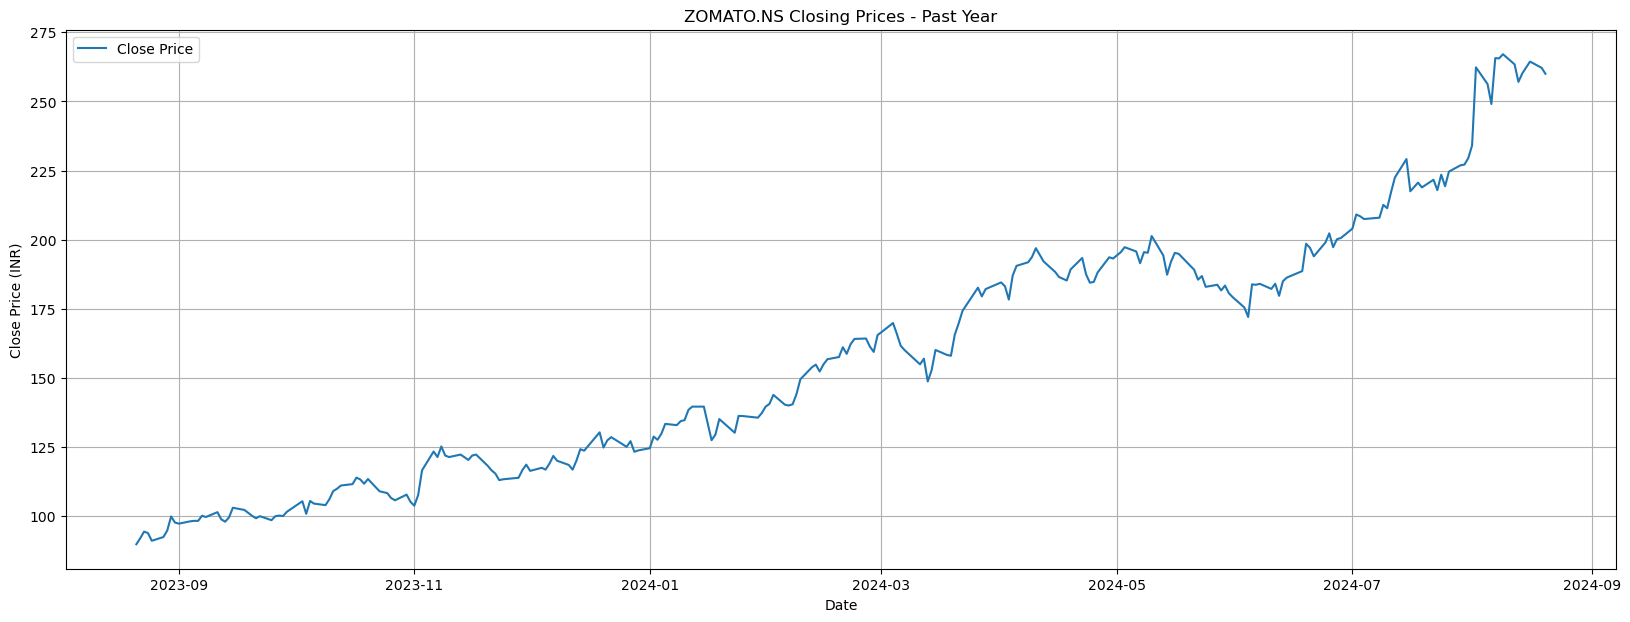

In [12]:
plt.figure(figsize=(20, 7))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title(ticker+' Closing Prices - Past Year')
plt.xlabel('Date')
plt.ylabel('Close Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
from numpy import log
result = adfuller(df['Close'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 1.388351
p-value: 0.997061


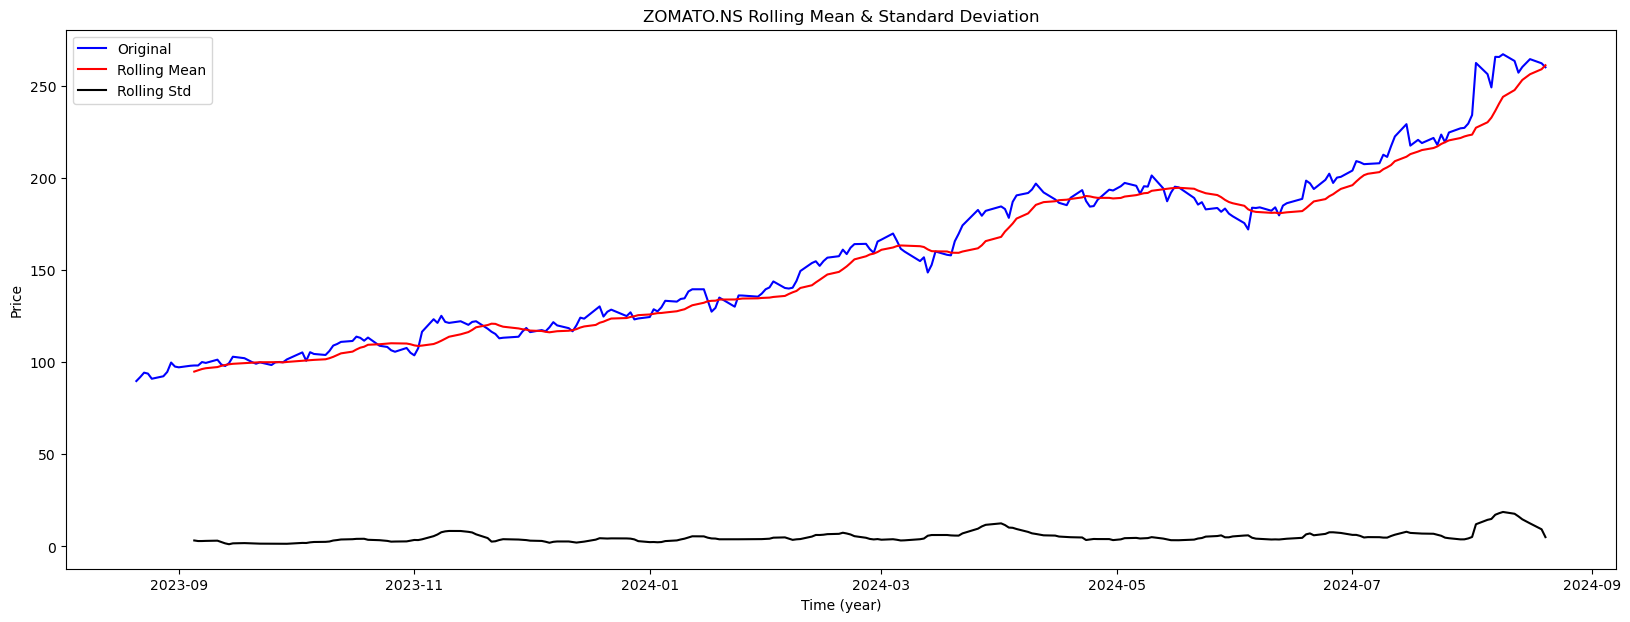

In [15]:
#Determing rolling statistics
rollmean = df['Close'].rolling(12).mean()
rollstd = df['Close'].rolling(12).std()
#Plot rolling statistics:
plt.figure(figsize=(20, 7), dpi=100)
plt.plot(df['Close'], color='blue', label='Original')
plt.plot(rollmean, color='red', label='Rolling Mean')
plt.plot(rollstd, color='black', label='Rolling Std')

plt.legend(loc='best')
plt.title(ticker+' Rolling Mean & Standard Deviation')
plt.xlabel('Time (year)')  # Labeling the x-axis
plt.ylabel('Price')  # Labeling the y-axis

plt.show()

In [16]:
def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [17]:
adfuller_test(df['Close'])

ADF Test Statistic : 1.3883509560139515
p-value : 0.9970605743012415
#Lags Used : 15
Number of Observations Used : 228
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


# Differencing

In [18]:
df['Close First Difference']=df['Close']-df['Close'].shift(1)

In [19]:
df['Close'].shift(1)

2023-08-21           NaN
2023-08-22     89.750000
2023-08-23     91.900002
2023-08-24     94.300003
2023-08-25     93.800003
                 ...    
2024-08-13    263.429993
2024-08-14    257.079987
2024-08-16    260.140015
2024-08-19    264.429993
2024-08-20    262.170013
Name: Close, Length: 244, dtype: float64

In [20]:
adfuller_test(df['Close First Difference'].dropna())

ADF Test Statistic : -3.8214497377553256
p-value : 0.00269532457204843
#Lags Used : 14
Number of Observations Used : 228
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


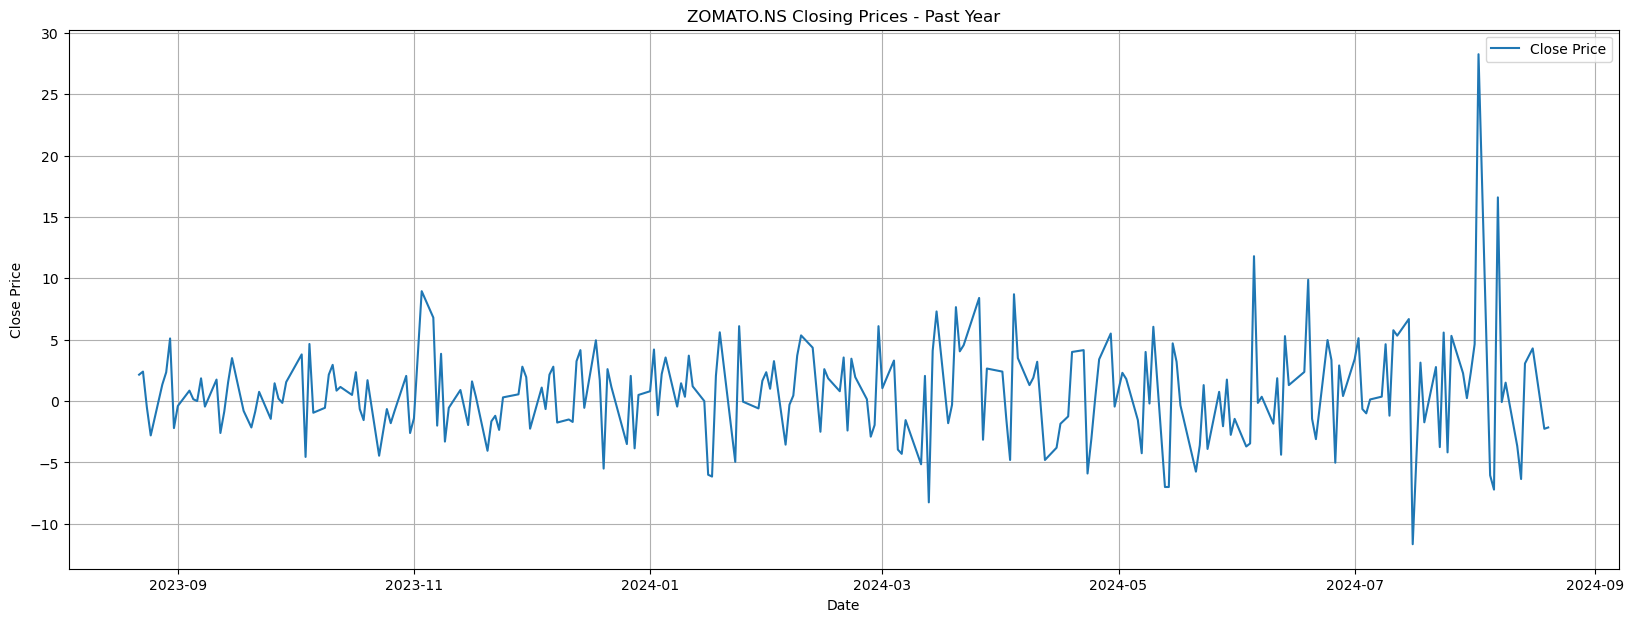

In [21]:
plt.figure(figsize=(20, 7))
plt.plot(df.index, df['Close First Difference'], label='Close Price')
plt.title(ticker+' Closing Prices - Past Year')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

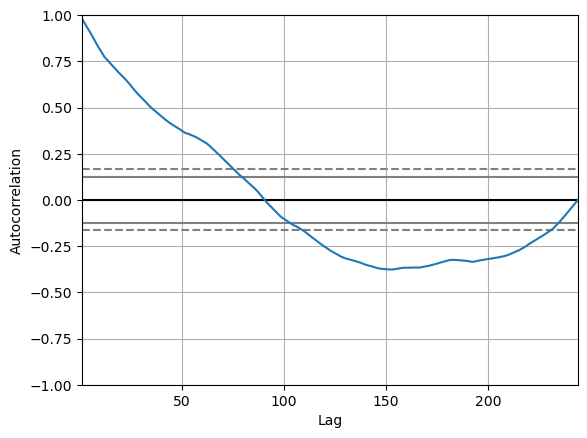

In [22]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Close'])
plt.show()

In [23]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [24]:
import statsmodels.api as sm

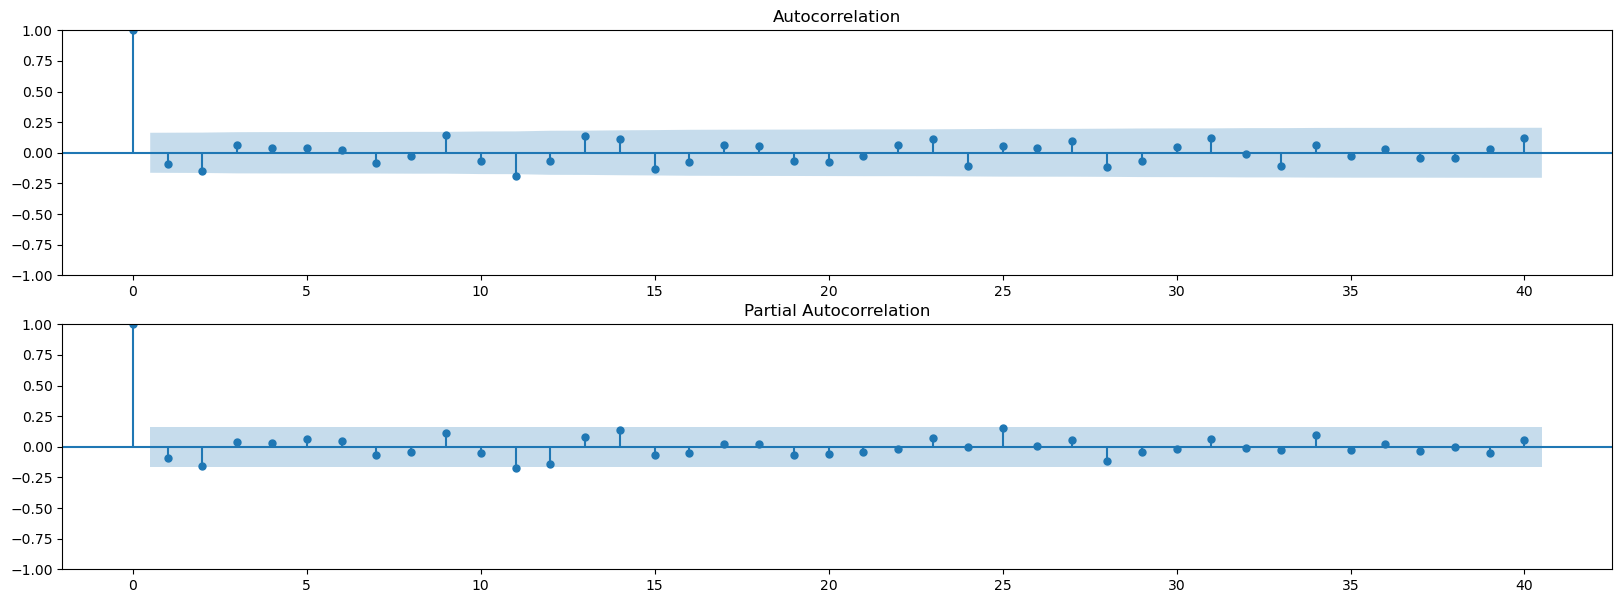

In [25]:
fig = plt.figure(figsize=(20,7))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Close First Difference'].iloc[100:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Close First Difference'].iloc[100:],lags=40,ax=ax2)

In [26]:
order=(2,1,2)
seasonal_order=(order[0],order[1],order[2],12)

# ARIMA

In [27]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [28]:
# Split the data into training and testing sets
train_size = int(len(df["Close"]) * 0.7)
test_size = len(df["Close"]) - train_size
train, test = df["Close"][:train_size], df["Close"][train_size:]

print(f"Training set size: {train_size}")
print(f"Testing set size: {test_size}")

Training set size: 170
Testing set size: 74


In [29]:
model = ARIMA(df.Close, order=order)
model_fit=model.fit()

D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [30]:
# Make predictions on the test set
start_index = len(train)
end_index = len(train) + len(test) - 1
predictions = model_fit.predict(start=start_index, end=end_index, typ='levels')

# Calculate and print the mean squared error
mse = mean_squared_error(test, predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 31.39111458680551


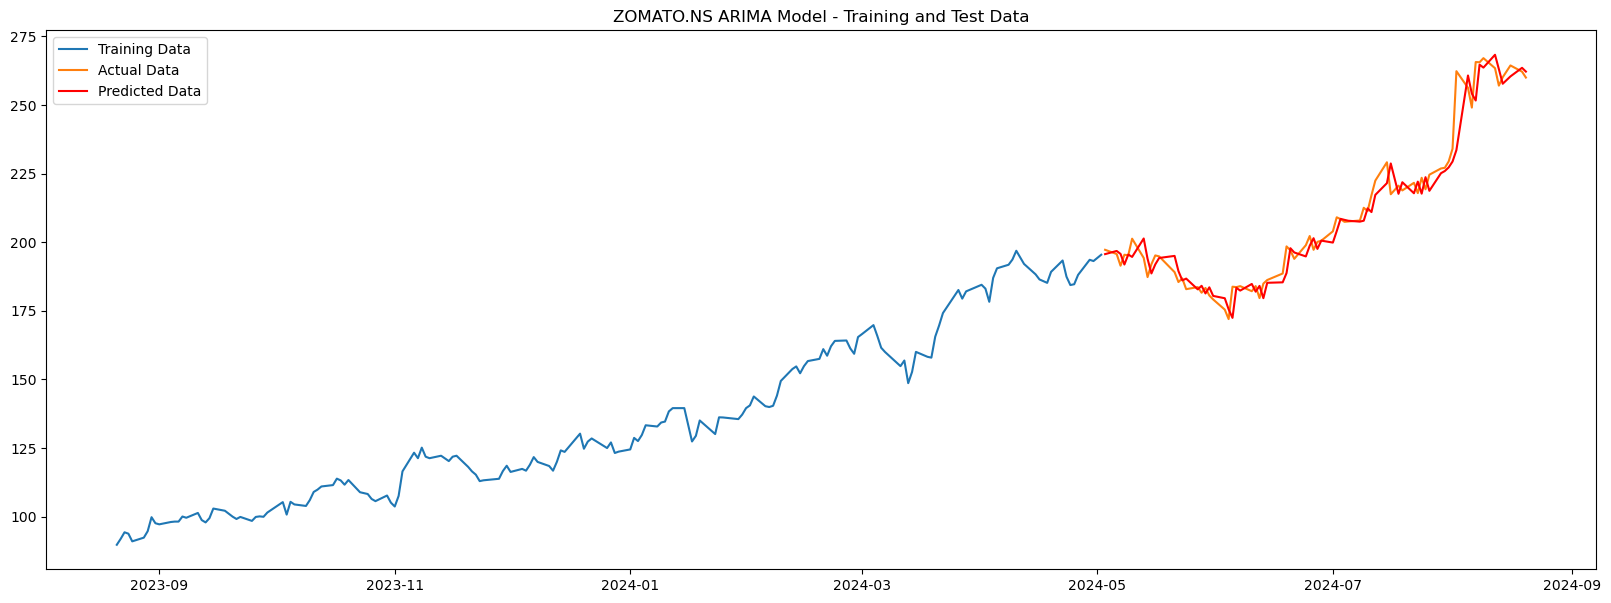

In [31]:
# Plot the actual values and the predictions
plt.figure(figsize=(20,7))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Data')
plt.plot(test.index, predictions, label='Predicted Data', color='red')
plt.legend(loc='upper left')
plt.title(ticker+' ARIMA Model - Training and Test Data')
plt.show()

<Axes: >

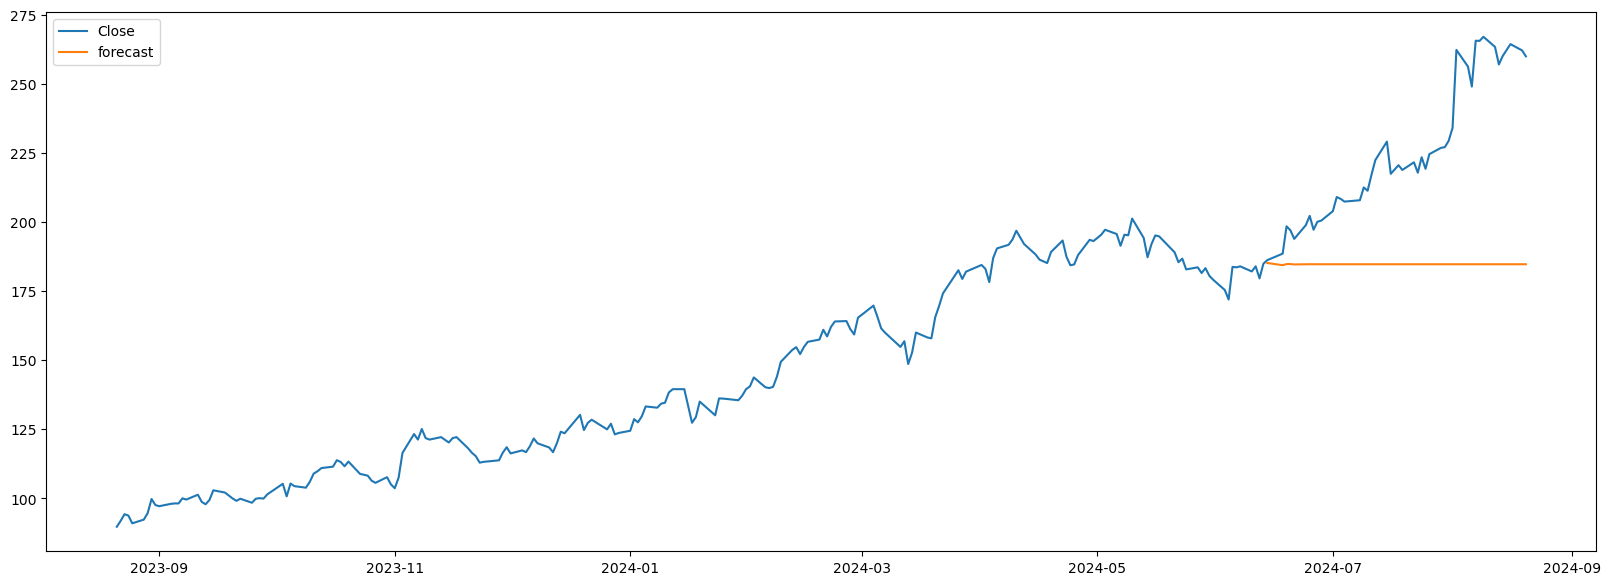

In [32]:
df['forecast']=model_fit.predict(start=len(df)-45,end=len(df)-1,dynamic=True)
df[['Close','forecast']].plot(figsize=(20,7))

In [33]:
import statsmodels.api as sm

In [34]:
model=sm.tsa.statespace.SARIMAX(df['Close'],seasonal_order=seasonal_order)
results=model.fit()

D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Data\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: >

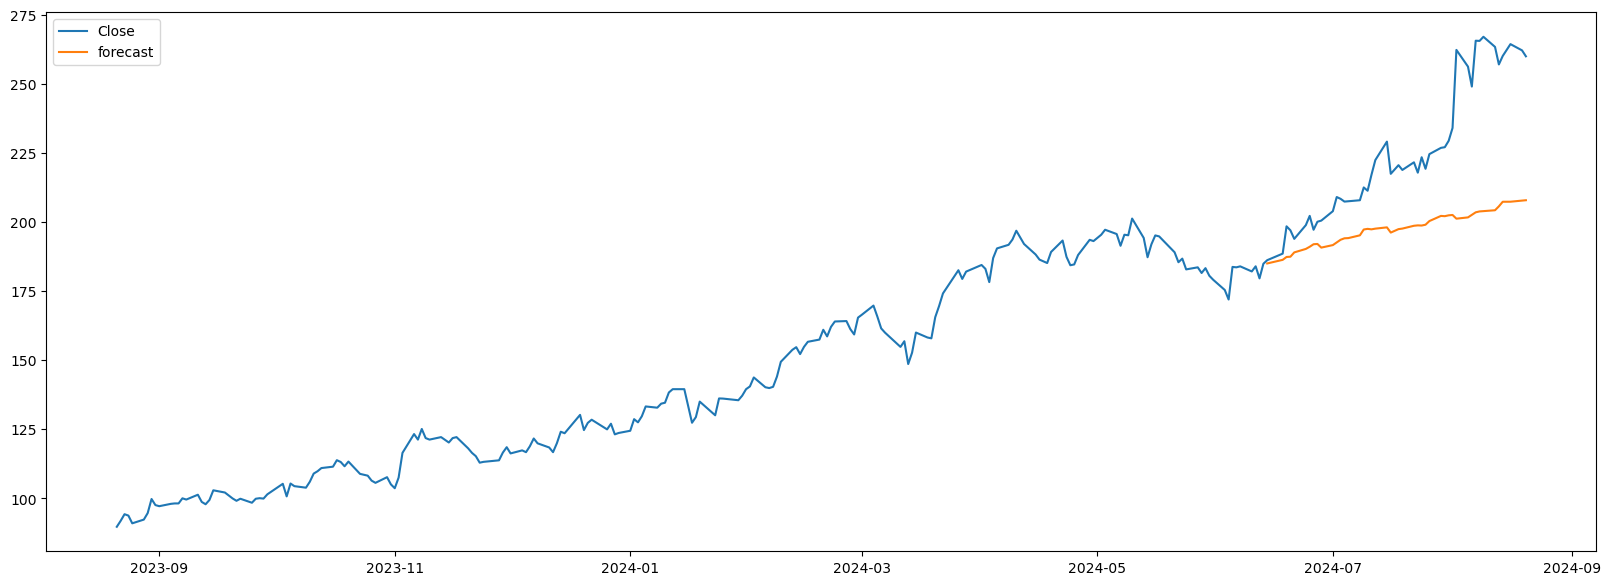

In [35]:
df['forecast']=results.predict(start=len(df)-45,end=len(df)-1,dynamic=True)
df[['Close','forecast']].plot(figsize=(20,7))

# Auto ARIMA

In [36]:
model = auto_arima(df["Close"], seasonal=False, trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1375.629, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1373.879, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1374.317, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1373.804, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1379.031, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1374.591, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1372.642, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1373.825, Time=0.11 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1373.445, Time=0.10 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1375.196, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1380.764, Time=0.04 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 0.922 seconds


In [37]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  244
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -682.321
Date:                Tue, 20 Aug 2024   AIC                           1372.642
Time:                        10:13:47   BIC                           1386.615
Sample:                             0   HQIC                          1378.270
                                - 244                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7024      0.234      2.998      0.003       0.243       1.162
ma.L1         -0.0769      0.063     -1.223      0.221      -0.200       0.046
ma.L2         -0.1142      0.063     -1.808      0.0

In [38]:
model_fit=model.fit(df["Close"])

In [39]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  244
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -682.321
Date:                Tue, 20 Aug 2024   AIC                           1372.642
Time:                        10:13:47   BIC                           1386.615
Sample:                             0   HQIC                          1378.270
                                - 244                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7024      0.234      2.998      0.003       0.243       1.162
ma.L1         -0.0769      0.063     -1.223      0.221      -0.200       0.046
ma.L2         -0.1142      0.063     -1.808      0.0

# Forecast

In [40]:
# Forecast for the next 30 days
n_periods = 30
forecast, conf_int = model_fit.predict(n_periods=n_periods, return_conf_int=True)

D:\Data\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [41]:
# Create a DataFrame for the forecast
forecast_index = pd.date_range(start=df['Close'].index[-1] + timedelta(days=0), periods=n_periods, freq='B')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecast'])
conf_int_df = pd.DataFrame(conf_int, index=forecast_index, columns=['Lower Bound', 'Upper Bound'])

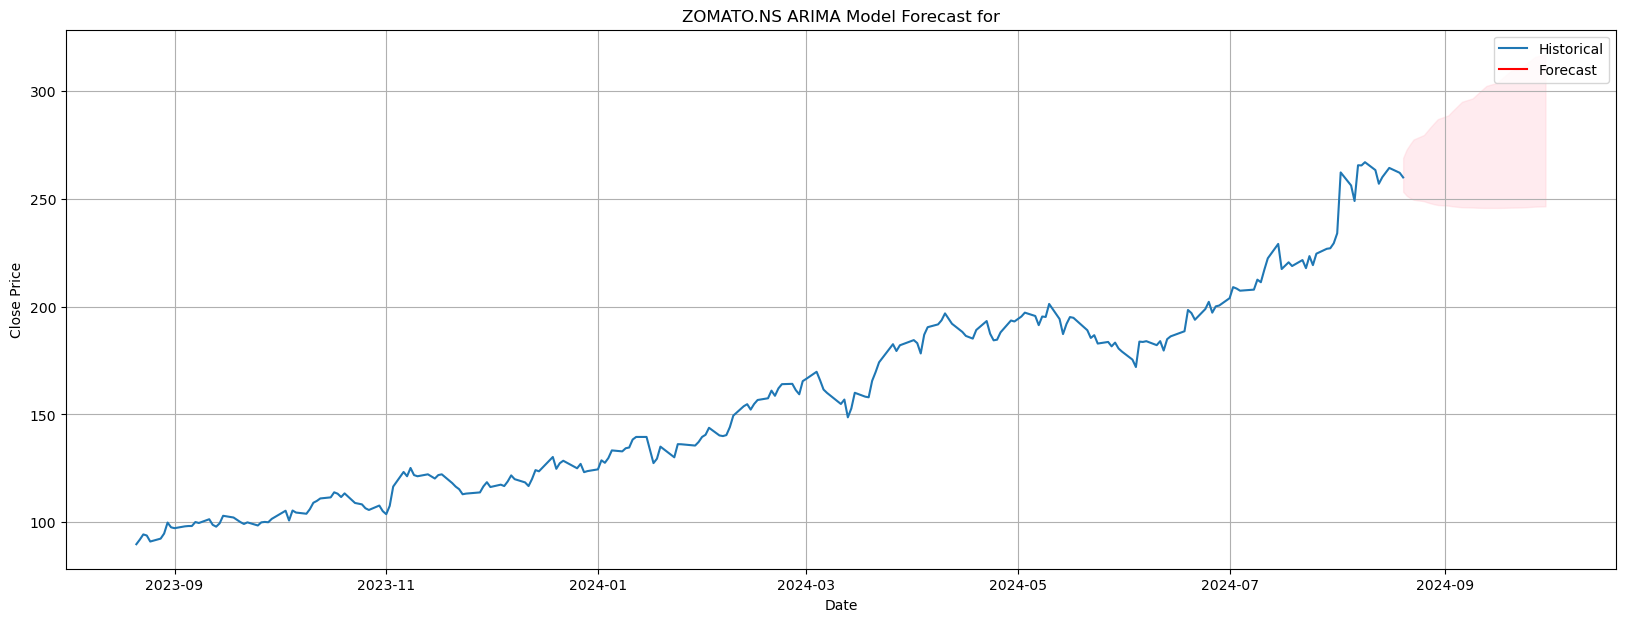

In [42]:
# Plot the results
plt.figure(figsize=(20,7))
plt.plot(df['Close'].index, df['Close'], label='Historical')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='red')
plt.fill_between(conf_int_df.index, conf_int_df['Lower Bound'], conf_int_df['Upper Bound'], color='pink', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(ticker+' ARIMA Model Forecast for')
plt.legend()
plt.grid(True)
plt.show()

# Risk Calculator

In [43]:
daily_returns = df['Close'].pct_change().dropna()
daily_returns.head()

2023-08-22    0.023955
2023-08-23    0.026115
2023-08-24   -0.005302
2023-08-25   -0.029851
2023-08-28    0.014835
Name: Close, dtype: float64

In [44]:
dvol=daily_returns.std()
mvol=dvol*math.sqrt(20)
avol=mvol*math.sqrt(245)
downside = daily_returns[daily_returns < 0]
downside_std= downside.std()
upside = daily_returns[daily_returns > 0]
upside_std= upside.std()

In [45]:
print(f"Daily Volatility: {dvol*100:.2f}%")
print(f"Monthly Volatility: {mvol*100:.2f}%")
print(f"Annual Volatility: {avol*100:.2f}%\n")
print(f"Upside Profit: {upside_std * 100:.2f}%  Downside Risk: {downside_std * 100:.2f}%")

Daily Volatility: 2.40%
Monthly Volatility: 10.74%
Annual Volatility: 168.10%

Upside Profit: 1.73%  Downside Risk: 1.20%
